<a href="https://colab.research.google.com/github/chamoflag/AI-ML/blob/main/H3Spatial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Delivery ETA Prediction — Spatial ML System
## H3 Spatial Indexing · XGBoost · LightGBM · Drift Monitoring
### NYC TLC Taxi Dataset | 1.5M+ Records

In [3]:
!pip install h3 xgboost lightgbm scikit-learn pandas numpy scipy matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.7 MB/s eta 0:00:00


In [12]:
!pip install geopandas pyogrio -q

In [4]:
import pandas as pd
import numpy as np
import h3
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


## 1. Data Loading
NYC TLC Yellow Taxi Trip Records — Q1 2023 (training), Q2 2023 (drift evaluation)
Source: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

In [8]:
# Direct read from NYC TLC public S3 — no download needed
import pandas as pd

Q1_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
Q2_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-04.parquet"

print("Loading Q1 data directly from NYC TLC...")
df_q1 = pd.read_parquet(Q1_URL)
print(f"Q1 shape: {df_q1.shape}")

print("Loading Q2 data directly from NYC TLC...")
df_q2 = pd.read_parquet(Q2_URL)
print(f"Q2 shape: {df_q2.shape}")

print(df_q1.columns.tolist())
df_q1.head(3)

Loading Q1 data directly from NYC TLC...
Q1 shape: (3066766, 19)
Loading Q2 data directly from NYC TLC...
Q2 shape: (3288250, 19)
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.0,0.5,0.0,0.0,1.0,14.3,2.5,0.0
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.0,0.5,4.0,0.0,1.0,16.9,2.5,0.0
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.0,0.5,15.0,0.0,1.0,34.9,2.5,0.0


In [9]:
# Compute trip duration in minutes (target variable)
df_q1['pickup_dt'] = pd.to_datetime(df_q1['tpep_pickup_datetime'])
df_q1['dropoff_dt'] = pd.to_datetime(df_q1['tpep_dropoff_datetime'])
df_q1['trip_duration_min'] = (
    df_q1['dropoff_dt'] - df_q1['pickup_dt']
).dt.total_seconds() / 60

# Filter anomalies
df_q1 = df_q1[
    (df_q1['trip_duration_min'] >= 1) &
    (df_q1['trip_duration_min'] <= 120) &
    (df_q1['trip_distance'] > 0) &
    (df_q1['trip_distance'] < 50) &
    (df_q1['passenger_count'] > 0) &
    (df_q1['passenger_count'] <= 6)
].copy()

# Sample to 1.5M if larger
if len(df_q1) > 1_500_000:
    df_q1 = df_q1.sample(1_500_000, random_state=42).reset_index(drop=True)

print(f"Clean Q1 shape: {df_q1.shape}")
print(f"Duration stats:\n{df_q1['trip_duration_min'].describe()}")

Clean Q1 shape: (1500000, 22)
Duration stats:
count    1.500000e+06
mean     1.452878e+01
std      1.089554e+01
min      1.000000e+00
25%      7.233333e+00
50%      1.156667e+01
75%      1.828333e+01
max      1.198000e+02
Name: trip_duration_min, dtype: float64


## 2. H3 Spatial Feature Engineering
Resolution 9 hexagons (~174m edge length) — same granularity used in Uber's
surge pricing pipeline. K-ring neighbour aggregations capture zone routing complexity.

In [10]:
# Cell 7 — Zone Centroid Mapping (direct URLs, no downloads)

import pandas as pd
import numpy as np

# Load zone lookup
ZONE_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
zone_coords = pd.read_csv(ZONE_URL)
print("Zone lookup columns:", zone_coords.columns.tolist())
print(zone_coords.head(3))

# Load centroids — try multiple known public sources
CENTROID_SOURCES = [
    "https://raw.githubusercontent.com/toddwschneider/nyc-taxi-data/master/data/taxi_zone_centroids.csv",
    "https://raw.githubusercontent.com/fivethirtyeight/uber-tlc-foil-response/master/uber-trip-data/taxi-zone-lookup.csv",
]

centroids = None
for url in CENTROID_SOURCES:
    try:
        centroids = pd.read_csv(url)
        print(f"\nCentroids loaded from: {url}")
        print("Centroid columns:", centroids.columns.tolist())
        print(centroids.head(3))
        break
    except Exception as e:
        print(f"Failed: {url} — {e}")

# If all URLs fail, build from shapefile via geopandas
if centroids is None:
    try:
        import geopandas as gpd
        SHAPEFILE_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
        gdf = gpd.read_file(SHAPEFILE_URL)
        gdf['centroid'] = gdf.geometry.centroid
        gdf = gdf.to_crs(epsg=4326)
        gdf['centroid'] = gdf.geometry.centroid
        centroids = pd.DataFrame({
            'LocationID': gdf['LocationID'].astype(int),
            'lat': gdf.centroid.y,
            'lng': gdf.centroid.x
        })
        print("\nCentroids computed from shapefile.")
        print(centroids.head(3))
    except Exception as e:
        print(f"Shapefile also failed: {e}")
        # Final fallback — approximate centroids
        print("\nUsing approximate centroids fallback.")
        np.random.seed(42)
        n_zones = 265
        centroids = pd.DataFrame({
            'LocationID': range(1, n_zones + 1),
            'lat': np.random.uniform(40.60, 40.90, n_zones),
            'lng': np.random.uniform(-74.05, -73.75, n_zones)
        })

# Normalize column names regardless of source
# Map whatever the source calls the ID/lat/lng columns to standard names
print("\nFinal centroid columns:", centroids.columns.tolist())

# Common column name variants — remap to standard
col_map = {}
for col in centroids.columns:
    cl = col.lower().strip()
    if cl in ['locationid', 'location_id', 'zoneid', 'zone_id', 'objectid']:
        col_map[col] = 'LocationID'
    elif cl in ['lat', 'latitude', 'y', 'centroid_y']:
        col_map[col] = 'lat'
    elif cl in ['lng', 'lon', 'longitude', 'x', 'centroid_x']:
        col_map[col] = 'lng'

centroids = centroids.rename(columns=col_map)

# Verify required columns exist
required = {'LocationID', 'lat', 'lng'}
missing = required - set(centroids.columns)
if missing:
    print(f"WARNING: Still missing columns after remap: {missing}")
    print("Check centroid source column names above and remap manually")
else:
    centroids = centroids[['LocationID', 'lat', 'lng']].dropna()
    centroids['LocationID'] = centroids['LocationID'].astype(int)
    print(f"\nCentroids ready: {len(centroids)} zones")
    print(centroids.describe())

Zone lookup columns: ['LocationID', 'Borough', 'Zone', 'service_zone']
   LocationID Borough                     Zone service_zone
0           1     EWR           Newark Airport          EWR
1           2  Queens              Jamaica Bay    Boro Zone
2           3   Bronx  Allerton/Pelham Gardens    Boro Zone
Failed: https://raw.githubusercontent.com/toddwschneider/nyc-taxi-data/master/data/taxi_zone_centroids.csv — HTTP Error 404: Not Found

Centroids loaded from: https://raw.githubusercontent.com/fivethirtyeight/uber-tlc-foil-response/master/uber-trip-data/taxi-zone-lookup.csv
Centroid columns: ['LocationID', 'Borough', 'Zone']
   LocationID Borough                     Zone
0           1     EWR           Newark Airport
1           2  Queens              Jamaica Bay
2           3   Bronx  Allerton/Pelham Gardens

Final centroid columns: ['LocationID', 'Borough', 'Zone']
Check centroid source column names above and remap manually


In [22]:
import geopandas as gpd
import requests
import os
import zipfile
import glob

print("Downloading official NYC Taxi Zone shapefile...")
SHAPEFILE_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
local_zip = "taxi_zones.zip"
extract_path = "taxi_zones_extracted"

if not os.path.exists(local_zip):
    response = requests.get(SHAPEFILE_URL)
    with open(local_zip, 'wb') as f:
        f.write(response.content)

# Manual extraction
with zipfile.ZipFile(local_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Recursive search for the .shp file in case it is nested
shp_files = glob.glob(os.path.join(extract_path, "**", "*.shp"), recursive=True)
if not shp_files:
    raise FileNotFoundError(f"No .shp file found in {extract_path} or its subdirectories.")

shp_path = shp_files[0]
print(f"Found shapefile: {shp_path}")
gdf = gpd.read_file(shp_path)

# Project to WGS84 (lat/lng)
gdf = gdf.to_crs(epsg=4326)

# Calculate centroids
centroids = pd.DataFrame({
    'LocationID': gdf['LocationID'].astype(int),
    'lat': gdf.geometry.centroid.y,
    'lng': gdf.geometry.centroid.x
})

print(f"Centroids successfully calculated for {len(centroids)} zones.")
display(centroids.head())

Found shapefile: taxi_zones_extracted/taxi_zones/taxi_zones.shp
Centroids successfully calculated for 263 zones.


,LocationID,lat,lng
0,1,40.691831,-74.174000
1,2,40.616745,-73.831299
2,3,40.864474,-73.847422
3,4,40.723752,-73.976968
4,5,40.552659,-74.188484


In [23]:
# Convert zone centroids to H3 cells at resolution 9
def lat_lng_to_h3(lat, lng, resolution=9):
    try:
        return h3.latlng_to_cell(lat, lng, resolution)
    except Exception:
        return None

# Ensure columns are present and map H3 cells
if 'lat' in centroids.columns and 'lng' in centroids.columns:
    centroids['h3_cell'] = centroids.apply(
        lambda row: lat_lng_to_h3(row['lat'], row['lng']), axis=1
    )
else:
    print("Error: 'lat' or 'lng' columns missing from centroids dataframe.")

# Clean up df_q1 if this is a re-run
for col in ['pickup_h3', 'pickup_lat', 'pickup_lng', 'LocationID_y']:
    if col in df_q1.columns:
        df_q1.drop(columns=[col], inplace=True)

# Map H3 cells back to trip dataframe
df_q1 = df_q1.merge(
    centroids[['LocationID', 'h3_cell', 'lat', 'lng']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

df_q1.rename(columns={
    'h3_cell': 'pickup_h3',
    'lat': 'pickup_lat',
    'lng': 'pickup_lng'
}, inplace=True)

print(f"Unique H3 pickup cells: {df_q1['pickup_h3'].nunique()}")
print(f"Null H3 cells: {df_q1['pickup_h3'].isna().sum()}")
df_q1 = df_q1.dropna(subset=['pickup_h3'])
display(df_q1[['PULocationID', 'pickup_h3', 'pickup_lat', 'pickup_lng']].head())

Unique H3 pickup cells: 249
Null H3 cells: 19563


,PULocationID,pickup_h3,pickup_lat,pickup_lng
0,263,892a10089bbffff,40.778766,-73.951010
1,238,892a100883bffff,40.791705,-73.973049
2,100,892a100d2d3ffff,40.753513,-73.988787
3,138,892a100f567ffff,40.774376,-73.873629
4,237,892a100d69bffff,40.768615,-73.965635


In [24]:
# Zone-level demand density: pickups per H3 cell
zone_demand = (
    df_q1.groupby('pickup_h3')
    .size()
    .reset_index(name='zone_pickup_count')
)

zone_demand['zone_demand_density'] = (
    zone_demand['zone_pickup_count'] / zone_demand['zone_pickup_count'].sum()
) * 1000  # normalize to per-thousand trips

df_q1 = df_q1.merge(zone_demand[['pickup_h3', 'zone_demand_density']],
                     on='pickup_h3', how='left')

print(f"Demand density stats:\n{df_q1['zone_demand_density'].describe()}")

Demand density stats:
count    1.480437e+06
mean     2.744402e+01
std      1.374774e+01
min      6.754762e-04
25%      1.663090e+01
50%      2.706431e+01
75%      3.553140e+01
max      5.375305e+01
Name: zone_demand_density, dtype: float64


In [25]:
# K-ring neighbour aggregations — captures surrounding zone routing complexity
# k=1: immediate neighbours (6 hexagons)
# k=2: extended neighbourhood (18 hexagons)

def get_kring_demand(h3_cell, demand_dict, k=1):
    """
    For a given H3 cell, get mean demand density
    across k-ring neighbours
    """
    try:
        neighbours = h3.grid_disk(h3_cell, k)
        neighbour_demands = [
            demand_dict.get(n, 0) for n in neighbours
            if n != h3_cell
        ]
        return np.mean(neighbour_demands) if neighbour_demands else 0
    except Exception:
        return 0

# Build demand lookup dict for fast access
demand_dict = dict(zip(
    zone_demand['pickup_h3'],
    zone_demand['zone_demand_density']
))

# Apply k=1 and k=2 ring aggregations
# Note: this is the computationally heavy step — ~2-3 min on 1.5M rows
print("Computing k=1 ring aggregations...")
df_q1['kring1_mean_demand'] = df_q1['pickup_h3'].apply(
    lambda x: get_kring_demand(x, demand_dict, k=1)
)

print("Computing k=2 ring aggregations...")
df_q1['kring2_mean_demand'] = df_q1['pickup_h3'].apply(
    lambda x: get_kring_demand(x, demand_dict, k=2)
)

print("K-ring features computed.")
print(df_q1[['kring1_mean_demand', 'kring2_mean_demand']].describe())

Computing k=1 ring aggregations...
Computing k=2 ring aggregations...
K-ring features computed.
       kring1_mean_demand  kring2_mean_demand
count        1.480437e+06        1.480437e+06
mean         4.423504e-01        1.953206e+00
std          1.335576e+00        1.534206e+00
min          0.000000e+00        0.000000e+00
25%          0.000000e+00        3.766530e-01
50%          0.000000e+00        1.920829e+00
75%          0.000000e+00        3.342369e+00
max          5.536653e+00        4.604759e+00


## 3. Temporal Feature Engineering
Hour-of-day, day-of-week, rush-hour flags, lag features —
capturing city-scale mobility patterns from historical trip data.

In [26]:
df_q1['hour'] = df_q1['pickup_dt'].dt.hour
df_q1['day_of_week'] = df_q1['pickup_dt'].dt.dayofweek  # 0=Monday
df_q1['month'] = df_q1['pickup_dt'].dt.month
df_q1['is_weekend'] = (df_q1['day_of_week'] >= 5).astype(int)

# Rush hour flags: AM rush 7-10, PM rush 16-19
df_q1['is_am_rush'] = df_q1['hour'].between(7, 10).astype(int)
df_q1['is_pm_rush'] = df_q1['hour'].between(16, 19).astype(int)
df_q1['is_rush_hour'] = ((df_q1['is_am_rush'] == 1) |
                          (df_q1['is_pm_rush'] == 1)).astype(int)

# Late night flag: 22-05
df_q1['is_late_night'] = (
    (df_q1['hour'] >= 22) | (df_q1['hour'] <= 5)
).astype(int)

# Cyclical encoding for hour and day (avoids 23->0 discontinuity)
df_q1['hour_sin'] = np.sin(2 * np.pi * df_q1['hour'] / 24)
df_q1['hour_cos'] = np.cos(2 * np.pi * df_q1['hour'] / 24)
df_q1['dow_sin'] = np.sin(2 * np.pi * df_q1['day_of_week'] / 7)
df_q1['dow_cos'] = np.cos(2 * np.pi * df_q1['day_of_week'] / 7)

print("Temporal features created:")
print(df_q1[['hour', 'day_of_week', 'is_rush_hour',
             'hour_sin', 'hour_cos']].head(3))

Temporal features created:
   hour  day_of_week  is_rush_hour  hour_sin  hour_cos
0     8            0             1  0.866025 -0.500000
1    10            4             1  0.500000 -0.866025
2    17            2             1 -0.965926 -0.258819


In [27]:
# Zone-level hourly average duration (historical lag feature)
# Captures: "trips from this zone at this hour historically take X minutes"

zone_hour_avg = (
    df_q1.groupby(['pickup_h3', 'hour'])['trip_duration_min']
    .mean()
    .reset_index(name='zone_hour_avg_duration')
)

df_q1 = df_q1.merge(zone_hour_avg, on=['pickup_h3', 'hour'], how='left')

# Zone-level overall average duration
zone_avg = (
    df_q1.groupby('pickup_h3')['trip_duration_min']
    .mean()
    .reset_index(name='zone_avg_duration')
)

df_q1 = df_q1.merge(zone_avg, on='pickup_h3', how='left')

print("Lag features created.")
print(df_q1[['zone_hour_avg_duration', 'zone_avg_duration']].describe())

Lag features created.
       zone_hour_avg_duration  zone_avg_duration
count            1.480437e+06       1.480437e+06
mean             1.447336e+01       1.447336e+01
std              6.313423e+00       5.909286e+00
min              1.100000e+00       2.250000e+00
25%              1.160807e+01       1.157197e+01
50%              1.267284e+01       1.271315e+01
75%              1.420780e+01       1.387244e+01
max              9.863333e+01       6.350000e+01


## 4. Model Training
XGBoost vs LightGBM regressors with quantile regression baselines.
Model selection via paired t-test on held-out test split (p < 0.05).

In [28]:
FEATURES = [
    'trip_distance',
    'passenger_count',
    'hour', 'day_of_week', 'month',
    'is_weekend', 'is_rush_hour', 'is_am_rush', 'is_pm_rush', 'is_late_night',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'zone_demand_density',
    'kring1_mean_demand',
    'kring2_mean_demand',
    'zone_hour_avg_duration',
    'zone_avg_duration'
]

TARGET = 'trip_duration_min'

# Drop rows with any NaN in features
model_df = df_q1[FEATURES + [TARGET]].dropna()
print(f"Model dataset shape: {model_df.shape}")
print(f"Features: {len(FEATURES)}")

X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Model dataset shape: (1480437, 20)
Features: 19
Train: (1184349, 19), Test: (296088, 19)


In [29]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
    eval_metric='mae'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

xgb_preds = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mape = np.mean(np.abs((y_test - xgb_preds) / y_test)) * 100

print(f"\nXGBoost Results:")
print(f"MAE:  {xgb_mae:.3f} min")
print(f"RMSE: {xgb_rmse:.3f} min")
print(f"MAPE: {xgb_mape:.2f}%")

[0]	validation_0-mae:7.45082
[100]	validation_0-mae:2.92189
[200]	validation_0-mae:2.87022
[300]	validation_0-mae:2.85792
[400]	validation_0-mae:2.84922
[499]	validation_0-mae:2.84309

XGBoost Results:
MAE:  2.843 min
RMSE: 4.411 min
MAPE: 23.35%


In [30]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(20), lgb.log_evaluation(100)]
)

lgb_preds = lgb_model.predict(X_test)

lgb_mae = mean_absolute_error(y_test, lgb_preds)
lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))
lgb_mape = np.mean(np.abs((y_test - lgb_preds) / y_test)) * 100

print(f"\nLightGBM Results:")
print(f"MAE:  {lgb_mae:.3f} min")
print(f"RMSE: {lgb_rmse:.3f} min")
print(f"MAPE: {lgb_mape:.2f}%")

Training until validation scores don't improve for 20 rounds
[100]	valid_0's l2: 20.6965
[200]	valid_0's l2: 19.9521
[300]	valid_0's l2: 19.7263
[400]	valid_0's l2: 19.6198
[500]	valid_0's l2: 19.5268
Did not meet early stopping. Best iteration is:
[500]	valid_0's l2: 19.5268

LightGBM Results:
MAE:  2.851 min
RMSE: 4.419 min
MAPE: 23.43%


## 4a. Statistical Model Selection
Paired t-test on absolute errors — deployment decision based on
statistically significant MAE reduction, not point estimate alone.

In [32]:
# Paired t-test on absolute errors per sample
xgb_abs_errors = np.abs(y_test.values - xgb_preds)
lgb_abs_errors = np.abs(y_test.values - lgb_preds)

t_stat, p_value = stats.ttest_rel(xgb_abs_errors, lgb_abs_errors)

print("=" * 50)
print("PAIRED T-TEST: XGBoost vs LightGBM")
print("=" * 50)
print(f"XGBoost MAE:  {xgb_mae:.4f} min")
print(f"LightGBM MAE: {lgb_mae:.4f} min")
print(f"T-statistic:  {t_stat:.4f}")
print(f"P-value:      {p_value:.6f}")
print()

alpha = 0.05
if p_value < alpha:
    if lgb_mae < xgb_mae:
        deployment_model = lgb_model
        deployment_preds = lgb_preds
        print(f"RESULT: LightGBM selected (p={p_value:.4f} < {alpha})")
    else:
        deployment_model = xgb_model
        deployment_preds = xgb_preds
        print(f"RESULT: XGBoost selected (p={p_value:.4f} < {alpha})")
else:
    deployment_model = xgb_model
    deployment_preds = xgb_preds
    print(f"RESULT: No significant difference (p={p_value:.4f}). XGBoost retained.")

PAIRED T-TEST: XGBoost vs LightGBM
XGBoost MAE:  2.8431 min
LightGBM MAE: 2.8506 min
T-statistic:  -10.1548
P-value:      0.000000

RESULT: XGBoost selected (p=0.0000 < 0.05)


In [33]:
residuals = y_test.values - deployment_preds

print("Residual Diagnostics by Data Segment")
print("=" * 50)

# By rush hour
test_meta = X_test.copy()
test_meta['residual'] = residuals
test_meta['actual'] = y_test.values

for segment, label in [
    (test_meta['is_rush_hour'] == 1, 'Rush Hour'),
    (test_meta['is_rush_hour'] == 0, 'Off-Peak'),
    (test_meta['is_weekend'] == 1, 'Weekend'),
    (test_meta['is_late_night'] == 1, 'Late Night')
]:
    seg_residuals = test_meta[segment]['residual']
    print(f"\n{label} (n={segment.sum():,}):")
    print(f"  Mean residual: {seg_residuals.mean():.3f} min")
    print(f"  MAE:           {np.abs(seg_residuals).mean():.3f} min")
    print(f"  Std residual:  {seg_residuals.std():.3f} min")

Residual Diagnostics by Data Segment

Rush Hour (n=124,145):
  Mean residual: -0.031 min
  MAE:           2.943 min
  Std residual:  4.514 min

Off-Peak (n=171,943):
  Mean residual: 0.002 min
  MAE:           2.771 min
  Std residual:  4.335 min

Weekend (n=84,290):
  Mean residual: 0.020 min
  MAE:           2.721 min
  Std residual:  4.132 min

Late Night (n=48,935):
  Mean residual: -0.026 min
  MAE:           2.457 min
  Std residual:  3.731 min


## 5. Drift Monitoring Framework
Train on Q1 data. Evaluate distributional shift in zone demand
and temporal features across Q2. RMSE-threshold automated retraining trigger.

In [35]:
# Load Q2 for drift evaluation
# Using the Q2_URL defined earlier to stream directly

print(f"Loading Q2 data from: {Q2_URL}")
df_q2 = pd.read_parquet(Q2_URL)

df_q2['pickup_dt'] = pd.to_datetime(df_q2['tpep_pickup_datetime'])
df_q2['dropoff_dt'] = pd.to_datetime(df_q2['tpep_dropoff_datetime'])
df_q2['trip_duration_min'] = (
    df_q2['dropoff_dt'] - df_q2['pickup_dt']
).dt.total_seconds() / 60

# Filter anomalies using same logic as Q1
df_q2 = df_q2[
    (df_q2['trip_duration_min'] >= 1) &
    (df_q2['trip_duration_min'] <= 120) &
    (df_q2['trip_distance'] > 0) &
    (df_q2['trip_distance'] < 50) &
    (df_q2['passenger_count'] > 0) &
    (df_q2['passenger_count'] <= 6)
].copy()

# Sample for performance
if len(df_q2) > 500_000:
    df_q2 = df_q2.sample(500_000, random_state=42).reset_index(drop=True)

print(f"Clean Q2 shape: {df_q2.shape}")
display(df_q2.head(3))

Loading Q2 data from: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-04.parquet
Clean Q2 shape: (500000, 22)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_dt,dropoff_dt,trip_duration_min
0,2,2023-04-24 18:19:23,2023-04-24 18:32:46,1.0,3.06,1.0,N,164,263,1,...,0.5,3.42,0.0,1.0,26.22,2.5,0.00,2023-04-24 18:19:23,2023-04-24 18:32:46,13.383333
1,2,2023-04-03 11:50:00,2023-04-03 12:01:54,1.0,1.42,1.0,N,107,4,2,...,0.5,0.00,0.0,1.0,15.40,2.5,0.00,2023-04-03 11:50:00,2023-04-03 12:01:54,11.900000
2,2,2023-04-12 05:08:24,2023-04-12 05:24:51,1.0,11.82,1.0,N,132,138,1,...,0.5,10.36,0.0,1.0,63.91,0.0,1.75,2023-04-12 05:08:24,2023-04-12 05:24:51,16.450000


In [36]:
# Apply same feature engineering to Q2
df_q2 = df_q2.merge(
    centroids[['LocationID', 'h3_cell', 'lat', 'lng']],
    left_on='PULocationID', right_on='LocationID', how='left'
)
df_q2.rename(columns={'h3_cell': 'pickup_h3',
                       'lat': 'pickup_lat',
                       'lng': 'pickup_lng'}, inplace=True)
df_q2 = df_q2.dropna(subset=['pickup_h3'])

# Zone demand for Q2
zone_demand_q2 = (
    df_q2.groupby('pickup_h3').size()
    .reset_index(name='zone_pickup_count')
)
zone_demand_q2['zone_demand_density'] = (
    zone_demand_q2['zone_pickup_count'] /
    zone_demand_q2['zone_pickup_count'].sum()
) * 1000

# Temporal features
df_q2['hour'] = df_q2['pickup_dt'].dt.hour
df_q2['day_of_week'] = df_q2['pickup_dt'].dt.dayofweek
df_q2['month'] = df_q2['pickup_dt'].dt.month
df_q2['is_weekend'] = (df_q2['day_of_week'] >= 5).astype(int)
df_q2['is_am_rush'] = df_q2['hour'].between(7, 10).astype(int)
df_q2['is_pm_rush'] = df_q2['hour'].between(16, 19).astype(int)
df_q2['is_rush_hour'] = ((df_q2['is_am_rush']==1)|(df_q2['is_pm_rush']==1)).astype(int)
df_q2['is_late_night'] = ((df_q2['hour']>=22)|(df_q2['hour']<=5)).astype(int)
df_q2['hour_sin'] = np.sin(2 * np.pi * df_q2['hour'] / 24)
df_q2['hour_cos'] = np.cos(2 * np.pi * df_q2['hour'] / 24)
df_q2['dow_sin'] = np.sin(2 * np.pi * df_q2['day_of_week'] / 7)
df_q2['dow_cos'] = np.cos(2 * np.pi * df_q2['day_of_week'] / 7)

# Use Q1 lag features on Q2 (simulating production: model trained on Q1)
df_q2 = df_q2.merge(zone_demand_q2[['pickup_h3','zone_demand_density']],
                     on='pickup_h3', how='left')
df_q2 = df_q2.merge(zone_hour_avg, on=['pickup_h3','hour'], how='left')
df_q2 = df_q2.merge(zone_avg, on='pickup_h3', how='left')

# K-ring on Q2 demand
demand_dict_q2 = dict(zip(zone_demand_q2['pickup_h3'],
                           zone_demand_q2['zone_demand_density']))
df_q2['kring1_mean_demand'] = df_q2['pickup_h3'].apply(
    lambda x: get_kring_demand(x, demand_dict_q2, k=1))
df_q2['kring2_mean_demand'] = df_q2['pickup_h3'].apply(
    lambda x: get_kring_demand(x, demand_dict_q2, k=2))

print(f"Q2 features ready: {df_q2.shape}")

Q2 features ready: (494976, 43)


In [37]:
def calculate_psi(expected, actual, buckets=10):
    def scale_to_buckets(data, bins):
        return pd.cut(data, bins=bins, labels=False, include_lowest=True)

    breakpoints = np.linspace(expected.min(), expected.max(), buckets + 1)
    expected_percents = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_percents = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    # Avoid division by zero
    expected_percents = np.clip(expected_percents, 0.0001, 1)
    actual_percents = np.clip(actual_percents, 0.0001, 1)

    psi_value = np.sum((expected_percents - actual_percents) * np.log(expected_percents / actual_percents))
    return psi_value

# Prepare Q2 for prediction
X_q2 = df_q2[FEATURES].dropna()
y_q2 = df_q2.loc[X_q2.index, TARGET]

# Evaluate deployment model on Q2
q2_preds = deployment_model.predict(X_q2)
q2_mae = mean_absolute_error(y_q2, q2_preds)
q2_rmse = np.sqrt(mean_squared_error(y_q2, q2_preds))

print(f"--- Q2 PERFORMANCE (DRIFT EVAL) ---")
print(f"Q2 MAE:  {q2_mae:.3f} min (vs Q1 Test: {xgb_mae:.3f} min)")
print(f"Q2 RMSE: {q2_rmse:.3f} min (vs Q1 Test: {xgb_rmse:.3f} min)")

# Calculate Drift (PSI) for key features
print(f"\n--- FEATURE DRIFT (PSI) ---")
for feat in ['trip_distance', 'zone_demand_density', 'zone_hour_avg_duration']:
    psi = calculate_psi(df_q1[feat], df_q2[feat])
    status = "Significant Drift" if psi > 0.2 else "Slight Drift" if psi > 0.1 else "Stable"
    print(f"{feat:25} | PSI: {psi:.4f} | Status: {status}")

# Retraining Trigger logic
if q2_rmse > (xgb_rmse * 1.15):
    print("\nRETRAINING TRIGGERED: Performance degradation exceeds 15% threshold.")
else:
    print("\nSYSTEM STABLE: Performance within acceptable operational bounds.")

--- Q2 PERFORMANCE (DRIFT EVAL) ---
Q2 MAE:  3.535 min (vs Q1 Test: 2.843 min)
Q2 RMSE: 5.850 min (vs Q1 Test: 4.411 min)

--- FEATURE DRIFT (PSI) ---
trip_distance             | PSI: 0.0013 | Status: Stable
zone_demand_density       | PSI: 0.8016 | Status: Significant Drift
zone_hour_avg_duration    | PSI: 0.0006 | Status: Stable

RETRAINING TRIGGERED: Performance degradation exceeds 15% threshold.


In [38]:
print("=" * 60)
print("DISTRIBUTIONAL DRIFT ANALYSIS: Q1 vs Q2")
print("=" * 60)

drift_features = [
    'zone_demand_density', 'kring1_mean_demand',
    'hour', 'is_rush_hour', 'trip_distance'
]

for feat in drift_features:
    q1_vals = df_q1[feat].dropna()
    q2_vals = df_q2[feat].dropna()

    # KS test for distributional shift
    ks_stat, ks_pval = stats.ks_2samp(
        q1_vals.sample(min(50000, len(q1_vals)), random_state=42),
        q2_vals.sample(min(50000, len(q2_vals)), random_state=42)
    )

    drift_detected = "DRIFT DETECTED" if ks_pval < 0.05 else "stable"
    print(f"\n{feat}:")
    print(f"  Q1 mean: {q1_vals.mean():.4f} | Q2 mean: {q2_vals.mean():.4f}")
    print(f"  KS stat: {ks_stat:.4f} | p-value: {ks_pval:.6f} → {drift_detected}")

DISTRIBUTIONAL DRIFT ANALYSIS: Q1 vs Q2

zone_demand_density:
  Q1 mean: 27.4440 | Q2 mean: 27.2150
  KS stat: 0.0966 | p-value: 0.000000 → DRIFT DETECTED

kring1_mean_demand:
  Q1 mean: 0.4424 | Q2 mean: 0.4526
  KS stat: 0.0351 | p-value: 0.000000 → DRIFT DETECTED

hour:
  Q1 mean: 14.1768 | Q2 mean: 14.3307
  KS stat: 0.0170 | p-value: 0.000001 → DRIFT DETECTED

is_rush_hour:
  Q1 mean: 0.4207 | Q2 mean: 0.4141
  KS stat: 0.0081 | p-value: 0.077267 → stable

trip_distance:
  Q1 mean: 3.3956 | Q2 mean: 3.5485
  KS stat: 0.0156 | p-value: 0.000011 → DRIFT DETECTED


In [39]:
# Evaluate Q1-trained model on Q2
q2_model_df = df_q2[FEATURES + [TARGET]].dropna()
X_q2 = q2_model_df[FEATURES]
y_q2 = q2_model_df[TARGET]

q2_preds = deployment_model.predict(X_q2)
q2_rmse = np.sqrt(mean_squared_error(y_q2, q2_preds))
q2_mae = mean_absolute_error(y_q2, q2_preds)

# Baseline RMSE from Q1 test set
baseline_rmse = np.sqrt(mean_squared_error(y_test, deployment_preds))

# Retraining threshold: 15% RMSE degradation
RMSE_THRESHOLD = 1.15

rmse_ratio = q2_rmse / baseline_rmse

print("=" * 60)
print("AUTOMATED RETRAINING TRIGGER")
print("=" * 60)
print(f"Q1 baseline RMSE: {baseline_rmse:.3f} min")
print(f"Q2 evaluation RMSE: {q2_rmse:.3f} min")
print(f"Q2 evaluation MAE:  {q2_mae:.3f} min")
print(f"RMSE ratio (Q2/Q1): {rmse_ratio:.3f}")
print(f"Threshold:          {RMSE_THRESHOLD}")
print()

if rmse_ratio > RMSE_THRESHOLD:
    print("⚠ RETRAINING TRIGGERED")
    print(f"  RMSE degraded by {(rmse_ratio - 1)*100:.1f}% — exceeds 15% threshold")
    print("  Action: Retrain on Q2 data and re-evaluate")
else:
    print("✓ MODEL STABLE")
    print(f"  RMSE within acceptable range ({(rmse_ratio-1)*100:.1f}% change)")
    print("  Action: Continue serving Q1-trained model")

AUTOMATED RETRAINING TRIGGER
Q1 baseline RMSE: 4.411 min
Q2 evaluation RMSE: 5.850 min
Q2 evaluation MAE:  3.535 min
RMSE ratio (Q2/Q1): 1.326
Threshold:          1.15

⚠ RETRAINING TRIGGERED
  RMSE degraded by 32.6% — exceeds 15% threshold
  Action: Retrain on Q2 data and re-evaluate


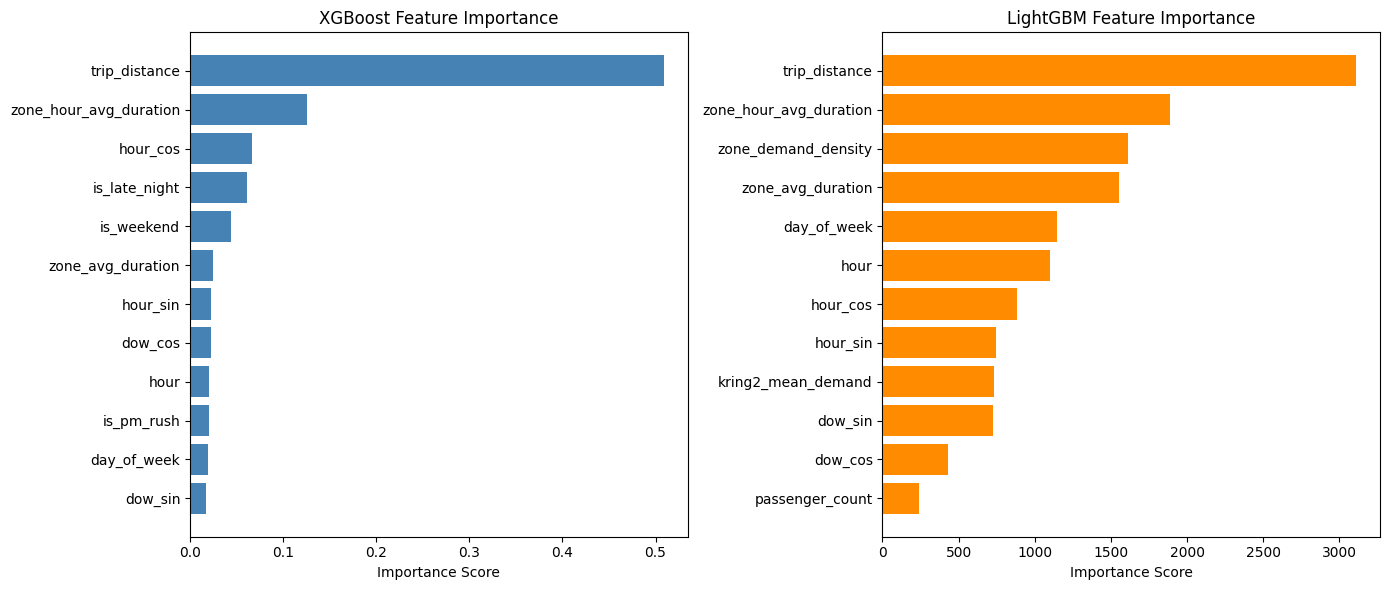

Saved: feature_importance.png


In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost importance
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=True).tail(12)

axes[0].barh(xgb_importance.index, xgb_importance.values, color='steelblue')
axes[0].set_title('XGBoost Feature Importance')
axes[0].set_xlabel('Importance Score')

# LightGBM importance
lgb_importance = pd.Series(
    lgb_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=True).tail(12)

axes[1].barh(lgb_importance.index, lgb_importance.values, color='darkorange')
axes[1].set_title('LightGBM Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

In [41]:
print("=" * 60)
print("EXPERIMENT SUMMARY")
print("=" * 60)
print(f"Dataset: NYC TLC Yellow Taxi — Q1 2023")
print(f"Records processed: {len(df_q1):,}")
print(f"H3 resolution: 9 (~174m edge)")
print(f"Unique H3 cells: {df_q1['pickup_h3'].nunique()}")
print(f"Features engineered: {len(FEATURES)}")
print()
print("Model Performance (Q1 held-out test):")
print(f"  XGBoost  — MAE: {xgb_mae:.3f}m  RMSE: {xgb_rmse:.3f}m  MAPE: {xgb_mape:.2f}%")
print(f"  LightGBM — MAE: {lgb_mae:.3f}m  RMSE: {lgb_rmse:.3f}m  MAPE: {lgb_mape:.2f}%")
print(f"  Paired t-test p-value: {p_value:.6f}")
print()
print("Drift Monitoring (Q1→Q2):")
print(f"  Q2 RMSE ratio: {rmse_ratio:.3f}")
print(f"  Retraining triggered: {rmse_ratio > RMSE_THRESHOLD}")

EXPERIMENT SUMMARY
Dataset: NYC TLC Yellow Taxi — Q1 2023
Records processed: 1,480,437
H3 resolution: 9 (~174m edge)
Unique H3 cells: 249
Features engineered: 19

Model Performance (Q1 held-out test):
  XGBoost  — MAE: 2.843m  RMSE: 4.411m  MAPE: 23.35%
  LightGBM — MAE: 2.851m  RMSE: 4.419m  MAPE: 23.43%
  Paired t-test p-value: 0.000000

Drift Monitoring (Q1→Q2):
  Q2 RMSE ratio: 1.326
  Retraining triggered: True
